# **Test Data Set**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.family"] = "DejaVu Sans"

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")

print("✅ ข้อมูล 5 แถวแรก")
print(df.head())

print("\n✅ ข้อมูลเบื้องต้น")
print(df.info())

✅ ข้อมูล 5 แถวแรก
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500  

In [ ]:
# =========================
# 2) Data Cleaning
# =========================

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Drop rows missing Embarked
df = df.dropna(subset=["Embarked"])

print("\n✅ Missing values หลัง clean:")
print(df.isnull().sum())



Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

✅ Missing values หลัง clean:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [ ]:
# =========================
# 3) Descriptive Statistics
# =========================

# Average Age
avg_age = df["Age"].mean()
print("Average Age:", avg_age)

# Survival rate by sex
survival_by_sex = df.groupby("Sex")["Survived"].mean()
print("\nSurvival Rate by Sex:")
print(survival_by_sex)

# Survival rate by class
survival_by_class = df.groupby("Pclass")["Survived"].mean()
print("\nSurvival Rate by Class:")
print(survival_by_class)

# Extra: survival by Embarked
survival_by_embarked = df.groupby("Embarked")["Survived"].mean()
print("\nSurvival Rate by Embarked:")
print(survival_by_embarked)


Average Age: 29.315151856017994

Survival Rate by Sex:
Sex
female    0.740385
male      0.188908
Name: Survived, dtype: float64

Survival Rate by Class:
Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival Rate by Embarked:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


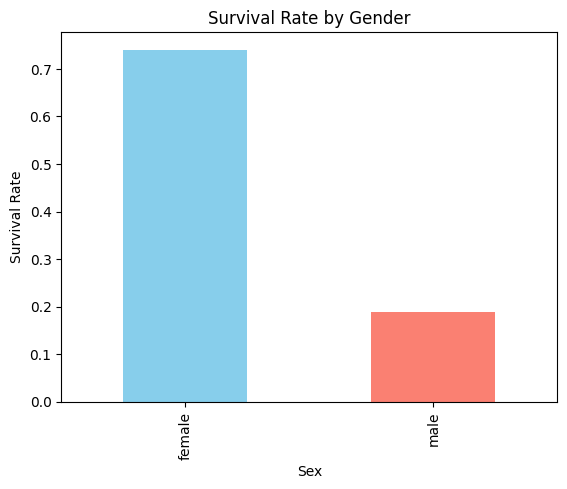

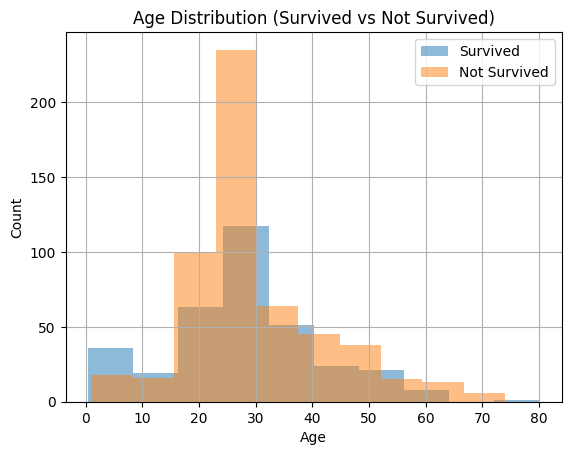

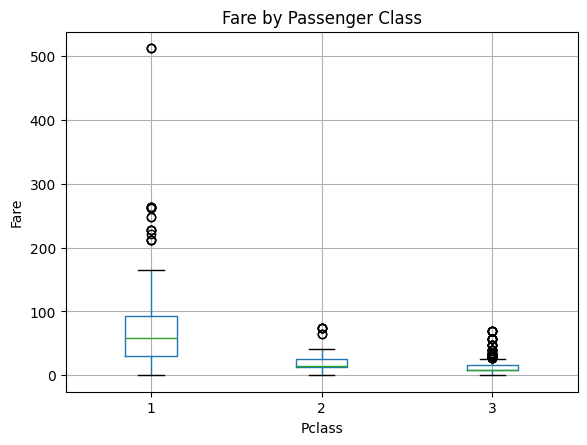

In [ ]:
# =========================
# 4) Visualization
# =========================

# --- Bar Chart: survival rate by gender ---
survival_by_sex.plot(kind="bar", color=["skyblue","salmon"])
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()

# --- Histogram: Age distribution survivors vs non-survivors ---
df[df["Survived"]==1]["Age"].hist(alpha=0.5, label="Survived")
df[df["Survived"]==0]["Age"].hist(alpha=0.5, label="Not Survived")
plt.legend()
plt.title("Age Distribution (Survived vs Not Survived)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# --- Boxplot: Fare by Pclass ---
df.boxplot(column="Fare", by="Pclass")
plt.title("Fare by Passenger Class")
plt.suptitle("")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()


In [ ]:
# =========================
# 5) Insights
# =========================
print("📌 Insights:")
print("- Women had much higher survival rate than men.")
print("- 1st class passengers had higher survival than 3rd class.")
print("- Fare correlates with survival (higher fare → higher survival chance).")
print("- Age shows slight pattern: children had better survival rates.")
print("\nThese features (Sex, Pclass, Fare, Age) are likely useful for ML models.")


📌 Insights:
- Women had much higher survival rate than men.
- 1st class passengers had higher survival than 3rd class.
- Fare correlates with survival (higher fare → higher survival chance).
- Age shows slight pattern: children had better survival rates.

These features (Sex, Pclass, Fare, Age) are likely useful for ML models.


# **Model 1: Random Forest**

In [ ]:
# =========================
# Data Preprocessing
# =========================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# โหลด dataset
df = pd.read_csv("Titanic-Dataset.csv")

# เลือกคอลัมน์ที่ใช้
df = df[["Survived", "Pclass", "Sex", "Age", "Fare", "Embarked"]]

# จัดการ missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df = df.dropna(subset=["Embarked"])

# แปลง categorical → numeric
df["Sex"] = LabelEncoder().fit_transform(df["Sex"])
df["Embarked"] = LabelEncoder().fit_transform(df["Embarked"])

# Features & Target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Scaling
X = StandardScaler().fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data ready for training")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


✅ Data ready for training
Train shape: (711, 5)
Test shape: (178, 5)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("🌲 Random Forest")
print("Accuracy:", rf_acc)
print("F1-score:", rf_f1)


🌲 Random Forest
Accuracy: 0.8033707865168539
F1-score: 0.7586206896551724


# **Extreme Learning Machine (ELM)**

In [ ]:
from sklearn.linear_model import LogisticRegression

class SimpleELM:
    def __init__(self, n_hidden=200, activation=np.tanh, random_state=42):
        self.n_hidden = n_hidden
        self.activation = activation
        self.random_state = np.random.RandomState(random_state)
        self.W = None
        self.model = LogisticRegression(max_iter=500)

    def _transform(self, X):
        H = self.activation(X @ self.W)
        return H

    def fit(self, X, y):
        self.W = self.random_state.normal(size=(X.shape[1], self.n_hidden))
        H = self._transform(X)
        self.model.fit(H, y)

    def predict(self, X):
        H = self._transform(X)
        return self.model.predict(H)

# Train ELM
elm = SimpleELM(n_hidden=200, activation=np.tanh)
elm.fit(X_train, y_train)
elm_pred = elm.predict(X_test)

elm_acc = accuracy_score(y_test, elm_pred)
elm_f1 = f1_score(y_test, elm_pred)

print("🤖 Custom ELM")
print("Accuracy:", elm_acc)
print("F1-score:", elm_f1)


🤖 Custom ELM
Accuracy: 0.8202247191011236
F1-score: 0.7777777777777778


# **Custom RVFL**

In [ ]:
class SimpleRVFL:
    def __init__(self, n_hidden=200, activation=np.tanh, random_state=42):
        self.n_hidden = n_hidden
        self.activation = activation
        self.random_state = np.random.RandomState(random_state)
        self.W = None
        self.model = LogisticRegression(max_iter=500)

    def _transform(self, X):
        H = self.activation(X @ self.W)
        # RVFL = concat input + hidden features
        return np.hstack([X, H])

    def fit(self, X, y):
        self.W = self.random_state.normal(size=(X.shape[1], self.n_hidden))
        H = self._transform(X)
        self.model.fit(H, y)

    def predict(self, X):
        H = self._transform(X)
        return self.model.predict(H)

# Train RVFL
rvfl = SimpleRVFL(n_hidden=200, activation=np.tanh)
rvfl.fit(X_train, y_train)
rvfl_pred = rvfl.predict(X_test)

rvfl_acc = accuracy_score(y_test, rvfl_pred)
rvfl_f1 = f1_score(y_test, rvfl_pred)

print("⚡ Custom RVFL")
print("Accuracy:", rvfl_acc)
print("F1-score:", rvfl_f1)


⚡ Custom RVFL
Accuracy: 0.8202247191011236
F1-score: 0.7777777777777778


# **Result & data plot**

📊 Performance Summary
               Accuracy  F1-score
Random Forest  0.803371  0.758621
ELM            0.820225  0.777778
RVFL           0.820225  0.777778


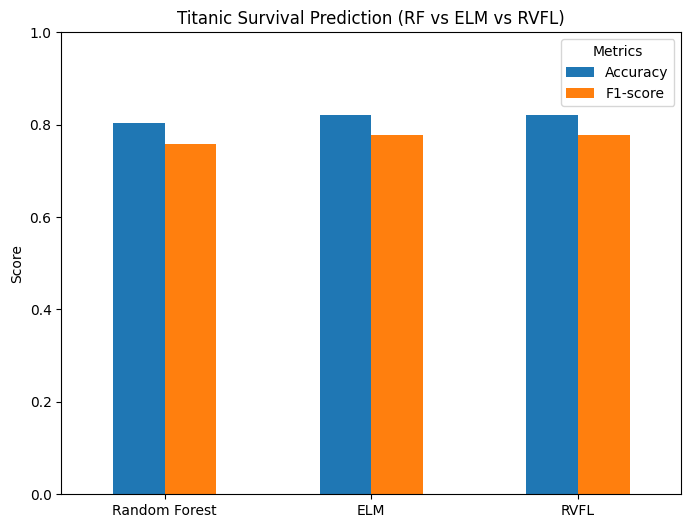

In [ ]:
import matplotlib.pyplot as plt

results = {
    "Random Forest": {"Accuracy": rf_acc, "F1-score": rf_f1},
    "ELM": {"Accuracy": elm_acc, "F1-score": elm_f1},
    "RVFL": {"Accuracy": rvfl_acc, "F1-score": rvfl_f1}
}

results_df = pd.DataFrame(results).T
print("📊 Performance Summary")
print(results_df)

# Plot
results_df.plot(kind="bar", figsize=(8,6))
plt.title("Titanic Survival Prediction (RF vs ELM vs RVFL)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(title="Metrics")
plt.show()

📊 Performance Summary
               Accuracy  F1-score
Random Forest  0.803371  0.758621
ELM            0.820225  0.777778
RVFL           0.820225  0.777778


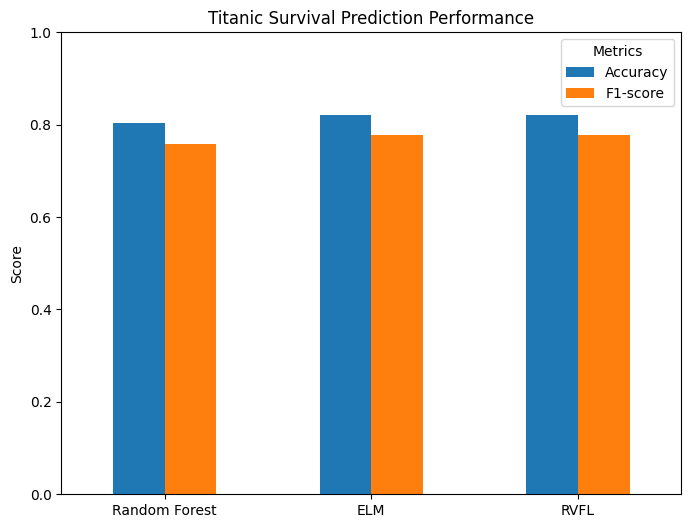

In [ ]:
# =========================
# Summary & Visualization
# =========================
import pandas as pd
import matplotlib.pyplot as plt

# รวมผลลัพธ์เป็น DataFrame
results = {
    "Random Forest": {"Accuracy": rf_acc, "F1-score": rf_f1},
    "ELM": {"Accuracy": elm_acc, "F1-score": elm_f1},
    "RVFL": {"Accuracy": rvfl_acc, "F1-score": rvfl_f1}
}

results_df = pd.DataFrame(results).T

# แสดงตาราง
print("📊 Performance Summary")
print(results_df)

# วาดกราฟ bar chart
ax = results_df.plot(kind="bar", figsize=(8,6))
plt.title("Titanic Survival Prediction Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metrics")
plt.show()